In [10]:
"""Active Field Estimation with Max Variance Sampling vs Uniform Random."""

import sys
from pathlib import Path


def add_project_root_to_path() -> Path:
    """Add repository root to sys.path. Works for both scripts and Jupyter notebooks."""
    if getattr(sys.modules.get("__main__", None), "__file__", None):
        # Script: project root is 3 levels up from experiments/field_estimation/scripts/*.py
        project_root = Path(sys.modules["__main__"].__file__).resolve().parents[3]
    else:
        # Notebook: walk up from cwd until we find project root (has src/ and pixi.toml)
        project_root = Path.cwd()
        for _ in range(10):
            if (project_root / "src").is_dir() and (
                project_root / "pixi.toml"
            ).exists():
                break
            parent = project_root.parent
            if parent == project_root:
                raise FileNotFoundError(
                    "Project root (directory with src/ and pixi.toml) not found."
                )
            project_root = parent
    root_str = str(project_root)
    if root_str not in sys.path:
        sys.path.insert(0, root_str)
    return project_root


add_project_root_to_path()

from jax import config


config.update("jax_enable_x64", True)

import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import gpjax as gpx
import optax as ox

from src.env.field.rff_gp_field import RFFGPField
from src.env.utils.types import GridConfig, GridPosition

In [11]:
# 1. Setup True Field
# ===================
grid_size = 50
sigma_true = 5.0
lengthscale_true = 7.5
nu_true = 2.5
noise_std_true = 0.2

seed = 42
key = jr.PRNGKey(seed)
key, field_key = jr.split(key)

grid_config = GridConfig.create(n_x=grid_size, n_y=grid_size)
field = RFFGPField(
    config=grid_config,
    d_max=4 * sigma_true,
    sigma=sigma_true,
    lengthscale=lengthscale_true,
    nu=nu_true,
    noise_std=noise_std_true,
)
field.reset(field_key)

true_u = field._precomputed_u.squeeze()  # shape (50, 50)

# Setup Test Grid for predictions and candidate generation
x_coords = jnp.arange(1, grid_size + 1)
y_coords = jnp.arange(1, grid_size + 1)
Xm, Ym = jnp.meshgrid(x_coords, y_coords, indexing="ij")
X_test = jnp.column_stack([Xm.ravel(), Ym.ravel()]).astype(jnp.float64)

M = 500
random_eval_interval = 50  # Evaluate random baseline RMSE every N samples
var_init = sigma_true**2
lengthscale_init = lengthscale_true

In [12]:
# 2. General Evaluation Function
# ==============================
def evaluate_gp(X_tr, y_tr, var_init=1.0, lengthscale_init=1.0, optimize=False):
    """Fit GP and return predictions and RMSE. Optionally optimize hyperparams."""
    dataset = gpx.Dataset(X=X_tr, y=y_tr)

    if optimize:
        kernel = gpx.kernels.Matern52(variance=var_init, lengthscale=lengthscale_init)
        prior = gpx.gps.Prior(mean_function=gpx.mean_functions.Zero(), kernel=kernel)
        likelihood = gpx.likelihoods.Gaussian(
            num_datapoints=dataset.n, obs_stddev=jnp.array([0.5])
        )
        posterior = prior * likelihood

        nmll = lambda p, d: -gpx.objectives.conjugate_mll(p, d)
        optim = ox.adam(learning_rate=0.05)
        opt_posterior, _ = gpx.fit(
            model=posterior,
            objective=nmll,
            train_data=dataset,
            optim=optim,
            num_iters=300,
        )

        v_opt = float(opt_posterior.prior.kernel.variance[...])
        l_opt = float(opt_posterior.prior.kernel.lengthscale[...])
        n_opt = float(opt_posterior.likelihood.obs_stddev[...][0])

        latent_dist = opt_posterior.predict(X_test, train_data=dataset)
    else:
        kernel = gpx.kernels.Matern52(variance=var_init, lengthscale=lengthscale_init)
        prior = gpx.gps.Prior(mean_function=gpx.mean_functions.Zero(), kernel=kernel)
        likelihood = gpx.likelihoods.Gaussian(
            num_datapoints=dataset.n, obs_stddev=jnp.array([noise_std_true])
        )
        posterior = prior * likelihood

        v_opt, l_opt, n_opt = var_init, lengthscale_init, noise_std_true
        latent_dist = posterior.predict(X_test, train_data=dataset)

    mu = latent_dist.mean.reshape(grid_size, grid_size)
    var = latent_dist.variance.reshape(grid_size, grid_size)
    rmse_val = jnp.sqrt(jnp.mean((true_u - mu) ** 2))

    return mu, var, float(rmse_val), (v_opt, l_opt, n_opt)

In [13]:
# 3. Shared Initial Samples
# =========================
b = 1  # Batch size for active learning
initial_samples = 50

key, sample_key = jr.split(key)
i_idx_init = jr.randint(sample_key, (initial_samples,), 1, grid_size + 1)
sample_key, _ = jr.split(sample_key)
j_idx_init = jr.randint(sample_key, (initial_samples,), 1, grid_size + 1)
X_init = jnp.column_stack([i_idx_init, j_idx_init]).astype(jnp.float64)

y_init_list = []
for idx in range(initial_samples):
    key, noise_key = jr.split(key)
    pos = GridPosition(int(X_init[idx, 0]), int(X_init[idx, 1]))
    disp = field.sample_displacement(pos, noise_key)
    y_init_list.append(jnp.array([disp.u]))
y_init = jnp.array(y_init_list)

# Evaluate shared starting point
mu_init, var_init_gp, rmse_init, _ = evaluate_gp(
    X_init, y_init, var_init, lengthscale_init, optimize=False
)
print(f"Shared initial {initial_samples} samples | RMSE = {rmse_init:.4f}")

Shared initial 50 samples | RMSE = 2.2747


In [14]:
# 4. Uniform Random Branch (continues from shared initial samples)
# ================================================================
remaining = M - initial_samples
key, sample_key = jr.split(key)

print(f"\nCollecting {remaining} additional Uniform Random samples...")
i_idx_extra = jr.randint(sample_key, (remaining,), 1, grid_size + 1)
sample_key, _ = jr.split(sample_key)
j_idx_extra = jr.randint(sample_key, (remaining,), 1, grid_size + 1)
X_extra_rand = jnp.column_stack([i_idx_extra, j_idx_extra]).astype(jnp.float64)

X_train_rand = jnp.concatenate([X_init, X_extra_rand], axis=0)
y_train_rand = jnp.concatenate([y_init, jnp.zeros((remaining, 1))], axis=0)

key, noise_key = jr.split(key)
noise_keys_rand = jr.split(noise_key, remaining)

for idx in range(remaining):
    pos = GridPosition(int(X_extra_rand[idx, 0]), int(X_extra_rand[idx, 1]))
    disp = field.sample_displacement(pos, noise_keys_rand[idx])
    y_train_rand = y_train_rand.at[initial_samples + idx, 0].set(disp.u)

# Evaluate random baseline RMSE at regular intervals (including shared start)
random_rmse_history = [rmse_init]
random_sample_counts = [initial_samples]
eval_points = list(range(
    initial_samples + random_eval_interval, M + 1, random_eval_interval
))
if not eval_points or eval_points[-1] != M:
    eval_points.append(M)

print(f"Evaluating random baseline at {len(eval_points)} checkpoints...")
for n in eval_points:
    _, _, rmse_n, _ = evaluate_gp(
        X_train_rand[:n], y_train_rand[:n], var_init, lengthscale_init, optimize=False
    )
    random_rmse_history.append(rmse_n)
    random_sample_counts.append(n)
    print(f"  Random N={n:<3} | RMSE = {rmse_n:.4f}")


Evaluating random baseline at 9 checkpoints...
  Random N=100 | RMSE = 1.3816
  Random N=150 | RMSE = 1.1027
  Random N=200 | RMSE = 0.9813
  Random N=250 | RMSE = 0.7240
  Random N=300 | RMSE = 0.5245
  Random N=350 | RMSE = 0.4590
  Random N=400 | RMSE = 0.4242
  Random N=450 | RMSE = 0.4086
  Random N=500 | RMSE = 0.4079


In [15]:
# 5. Active Branch — Max Variance (continues from shared initial samples)
# =======================================================================
X_train_act_list = list(X_init)
y_train_act_list = list(y_init)

X_train_act = X_init.copy()
y_train_act = y_init.copy()

active_rmse_history = [rmse_init]
active_sample_counts = [initial_samples]

# Start from the shared GP state
var_act = var_init_gp

print(f"\nStarting active learning... (Target M={M}, batch size={b})")
print(f"Collected {initial_samples:<3}/{M} samples | RMSE = {rmse_init:.4f}")

while len(X_train_act) < M:
    # Select top b locations with max variance
    top_indices = jnp.argsort(var_act.flatten())[-b:]
    X_batch = X_test[top_indices]

    for idx in range(b):
        key, noise_key = jr.split(key)
        pos = GridPosition(int(X_batch[idx, 0]), int(X_batch[idx, 1]))
        disp = field.sample_displacement(pos, noise_key)
        X_train_act_list.append(X_batch[idx])
        y_train_act_list.append(jnp.array([disp.u]))

    X_train_act = jnp.array(X_train_act_list)
    y_train_act = jnp.array(y_train_act_list)

    # Evaluate new dataset to update variance for next iteration and track RMSE
    mu_act, var_act, rmse_act, _ = evaluate_gp(
        X_train_act, y_train_act, var_init, lengthscale_init, optimize=False
    )

    active_rmse_history.append(rmse_act)
    active_sample_counts.append(len(X_train_act))
    print(f"Collected {len(X_train_act):<3}/{M} samples | RMSE = {rmse_act:.4f}")


Starting active learning... (Target M=500, batch size=1)
Collected 50 /500 samples | RMSE = 2.2747
Collected 51 /500 samples | RMSE = 2.0743
Collected 52 /500 samples | RMSE = 2.0701
Collected 53 /500 samples | RMSE = 2.0624
Collected 54 /500 samples | RMSE = 1.9490
Collected 55 /500 samples | RMSE = 1.9141
Collected 56 /500 samples | RMSE = 1.8862
Collected 57 /500 samples | RMSE = 1.8599
Collected 58 /500 samples | RMSE = 1.8693
Collected 59 /500 samples | RMSE = 1.6893
Collected 60 /500 samples | RMSE = 1.6903
Collected 61 /500 samples | RMSE = 1.6747
Collected 62 /500 samples | RMSE = 1.6753
Collected 63 /500 samples | RMSE = 1.6580
Collected 64 /500 samples | RMSE = 1.6569
Collected 65 /500 samples | RMSE = 1.6644
Collected 66 /500 samples | RMSE = 1.6329
Collected 67 /500 samples | RMSE = 1.5977
Collected 68 /500 samples | RMSE = 1.6016
Collected 69 /500 samples | RMSE = 1.5730
Collected 70 /500 samples | RMSE = 1.5230
Collected 71 /500 samples | RMSE = 1.5148
Collected 72 /500 

In [16]:
# 6. Final Evaluation (True Parameters)
# =====================================
print("\nEvaluating Final Random Dataset...")
mu_rand, var_rand, rmse_rand, _ = evaluate_gp(
    X_train_rand, y_train_rand, var_init, lengthscale_init, optimize=False
)

print("Evaluating Final Active Dataset...")
mu_act_final, var_act_final, rmse_act_final, _ = evaluate_gp(
    X_train_act, y_train_act, var_init, lengthscale_init, optimize=False
)


Evaluating Final Random Dataset...
Evaluating Final Active Dataset...


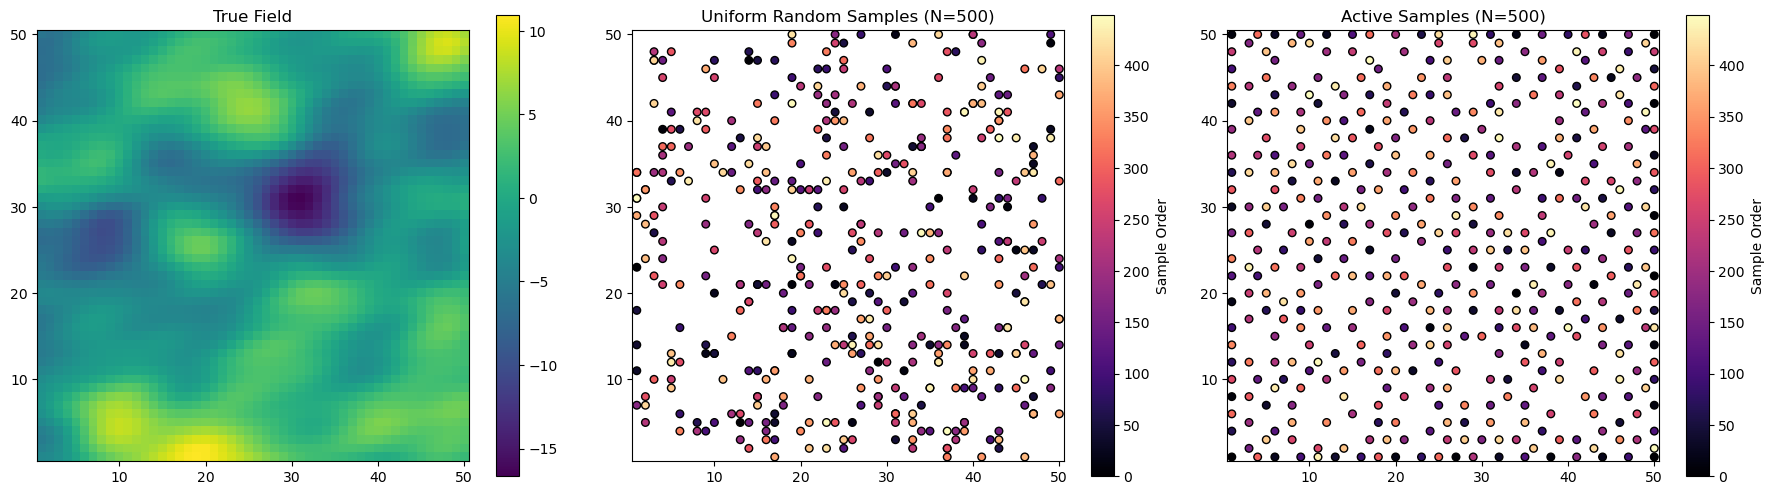

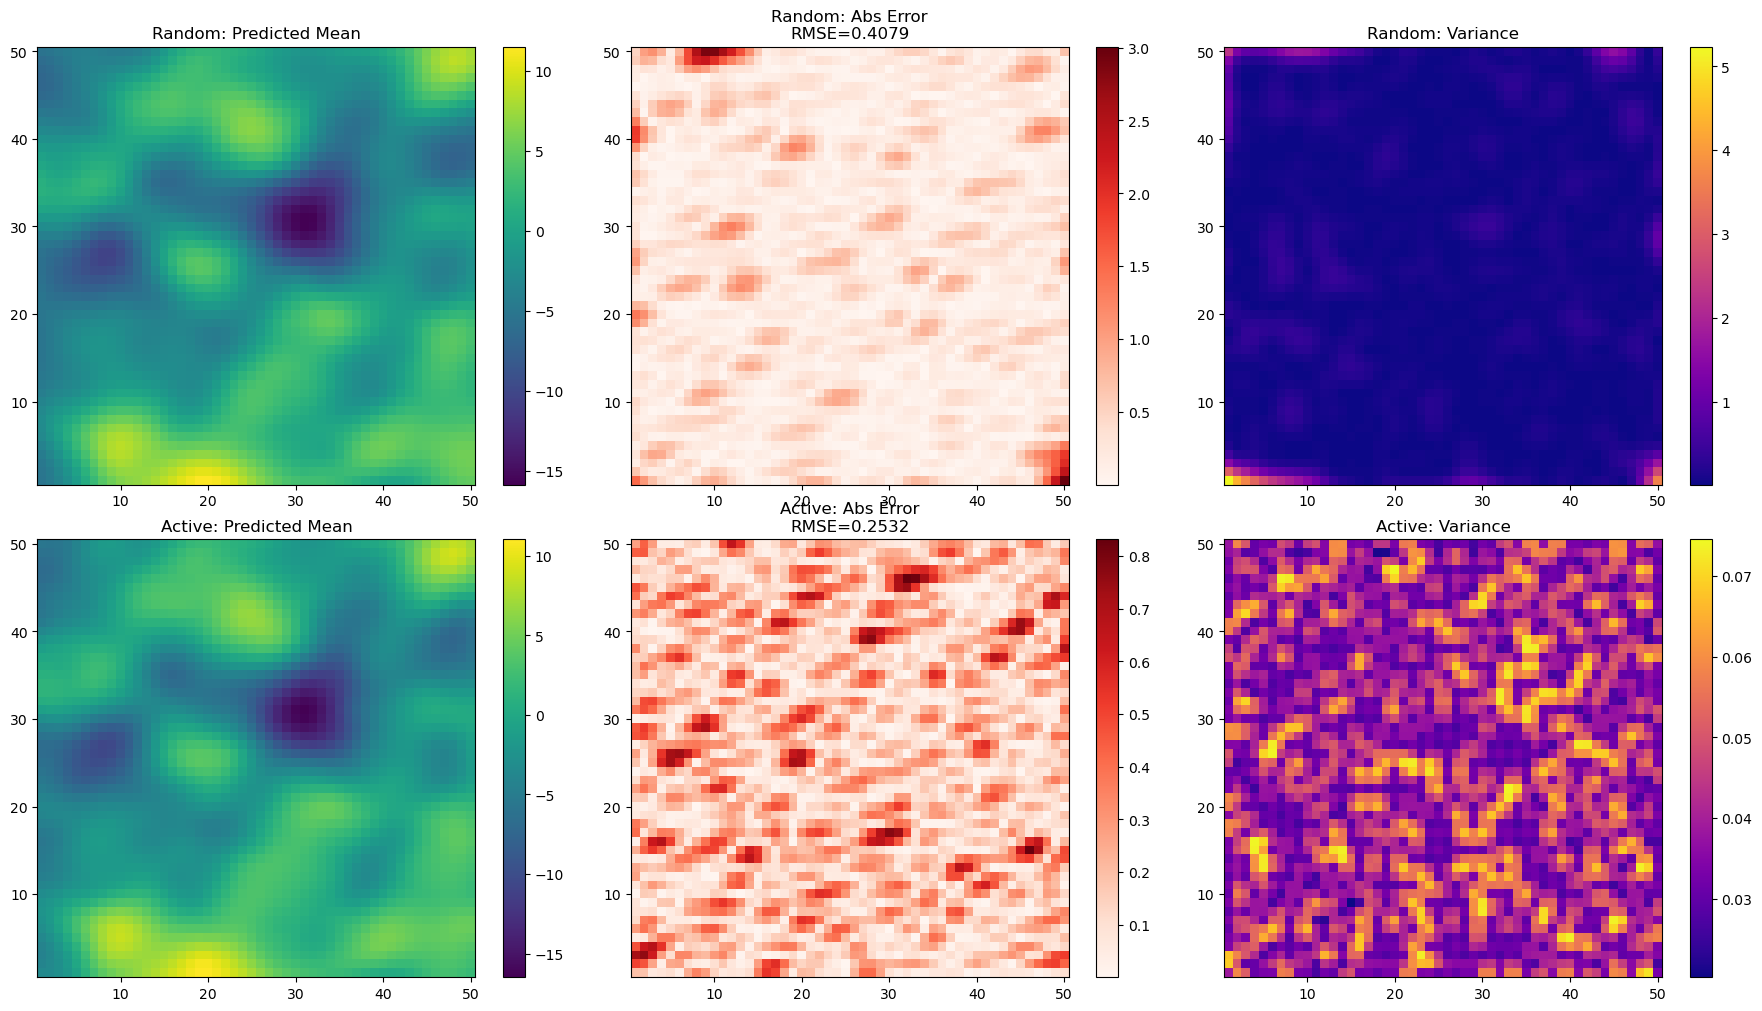

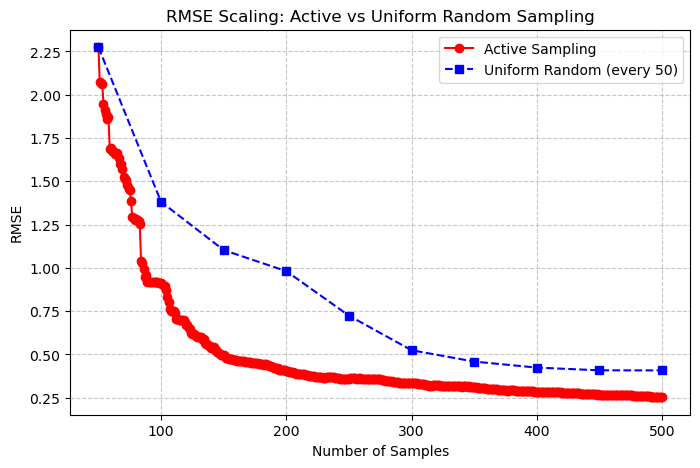

In [19]:
# 7. Plotting
# ===========

# Figure 1: True Field & Sample Heatmaps (1x3)
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes1[0].imshow(
    true_u.T,
    origin="lower",
    cmap="viridis",
    extent=[0.5, grid_size + 0.5, 0.5, grid_size + 0.5],
)
axes1[0].set_title("True Field")
plt.colorbar(im0, ax=axes1[0])

sample_order_rand = jnp.arange(len(X_train_rand[initial_samples:]))
sc1 = axes1[1].scatter(
    X_train_rand[initial_samples:, 0],
    X_train_rand[initial_samples:, 1],
    c=sample_order_rand,
    cmap="magma",
    edgecolors="k",
    s=30,
)
axes1[1].set_xlim(0.5, grid_size + 0.5)
axes1[1].set_ylim(0.5, grid_size + 0.5)
axes1[1].set_title(f"Uniform Random Samples (N={M})")
axes1[1].set_aspect("equal")
plt.colorbar(sc1, ax=axes1[1], label="Sample Order")

sample_order_act = jnp.arange(len(X_train_act[initial_samples:]))
sc2 = axes1[2].scatter(
    X_train_act[initial_samples:, 0],
    X_train_act[initial_samples:, 1],
    c=sample_order_act,
    cmap="magma",
    edgecolors="k",
    s=30,
)
axes1[2].set_xlim(0.5, grid_size + 0.5)
axes1[2].set_ylim(0.5, grid_size + 0.5)
axes1[2].set_title(f"Active Samples (N={M})")
axes1[2].set_aspect("equal")
plt.colorbar(sc2, ax=axes1[2], label="Sample Order")

plt.tight_layout()
plt.savefig("plots/active_estimation/active_estimation_sample_heatmaps.png")
plt.show()


# Figure 2: Random vs Active GP Posteriors (2x3)
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: Random
im_r1 = axes2[0, 0].imshow(
    mu_rand.T,
    origin="lower",
    cmap="viridis",
    extent=[0.5, grid_size + 0.5, 0.5, grid_size + 0.5],
)
axes2[0, 0].set_title("Random: Predicted Mean")
plt.colorbar(im_r1, ax=axes2[0, 0])

err_rand = jnp.abs(true_u - mu_rand)
im_r2 = axes2[0, 1].imshow(
    err_rand.T,
    origin="lower",
    cmap="Reds",
    extent=[0.5, grid_size + 0.5, 0.5, grid_size + 0.5],
)
axes2[0, 1].set_title(f"Random: Abs Error\nRMSE={rmse_rand:.4f}")
plt.colorbar(im_r2, ax=axes2[0, 1])

im_r3 = axes2[0, 2].imshow(
    var_rand.T,
    origin="lower",
    cmap="plasma",
    extent=[0.5, grid_size + 0.5, 0.5, grid_size + 0.5],
)
axes2[0, 2].set_title("Random: Variance")
plt.colorbar(im_r3, ax=axes2[0, 2])

# Row 2: Active
im_a1 = axes2[1, 0].imshow(
    mu_act_final.T,
    origin="lower",
    cmap="viridis",
    extent=[0.5, grid_size + 0.5, 0.5, grid_size + 0.5],
)
axes2[1, 0].set_title("Active: Predicted Mean")
plt.colorbar(im_a1, ax=axes2[1, 0])

err_act = jnp.abs(true_u - mu_act_final)
im_a2 = axes2[1, 1].imshow(
    err_act.T,
    origin="lower",
    cmap="Reds",
    extent=[0.5, grid_size + 0.5, 0.5, grid_size + 0.5],
)
axes2[1, 1].set_title(f"Active: Abs Error\nRMSE={rmse_act_final:.4f}")
plt.colorbar(im_a2, ax=axes2[1, 1])

im_a3 = axes2[1, 2].imshow(
    var_act_final.T,
    origin="lower",
    cmap="plasma",
    extent=[0.5, grid_size + 0.5, 0.5, grid_size + 0.5],
)
axes2[1, 2].set_title("Active: Variance")
plt.colorbar(im_a3, ax=axes2[1, 2])

plt.tight_layout()
plt.savefig("plots/active_estimation/active_estimation_gp_posteriors.png")
plt.show()

# Figure 3: RMSE Scaling — Active vs Uniform Random
plt.figure(figsize=(8, 5))
plt.plot(
    active_sample_counts,
    active_rmse_history,
    marker="o",
    linestyle="-",
    color="r",
    label="Active Sampling",
)
plt.plot(
    random_sample_counts,
    random_rmse_history,
    marker="s",
    linestyle="--",
    color="b",
    label=f"Uniform Random (every {random_eval_interval})",
)
plt.xlabel("Number of Samples")
plt.ylabel("RMSE")
plt.title("RMSE Scaling: Active vs Uniform Random Sampling")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.savefig("plots/active_estimation/active_estimation_rmse_scaling.png")
plt.show()

In [21]:
# Figure 4: Pre-compute error heatmaps for animation
# (Separate from plotting so the animation cell can be re-run cheaply)
gif_frame_step = 5  # Evaluate GP every N samples for animation frames

n_total = len(X_train_act)
frame_counts = list(range(initial_samples, n_total + 1, gif_frame_step))
if frame_counts[-1] != n_total:
    frame_counts.append(n_total)

error_frames = []
print(f"Pre-computing {len(frame_counts)} error heatmap frames...")
for i, n in enumerate(frame_counts):
    mu_n, _, _, _ = evaluate_gp(
        X_train_act[:n], y_train_act[:n], var_init, lengthscale_init, optimize=False
    )
    err_n = jnp.abs(true_u - mu_n)
    error_frames.append(err_n)
    if (i + 1) % 20 == 0 or n == n_total:
        print(f"  Frame {i + 1}/{len(frame_counts)} (N={n})")

print("Done pre-computing frames.")

Pre-computing 91 error heatmap frames...
  Frame 20/91 (N=145)
  Frame 40/91 (N=245)
  Frame 60/91 (N=345)
  Frame 80/91 (N=445)
  Frame 91/91 (N=500)
Done pre-computing frames.


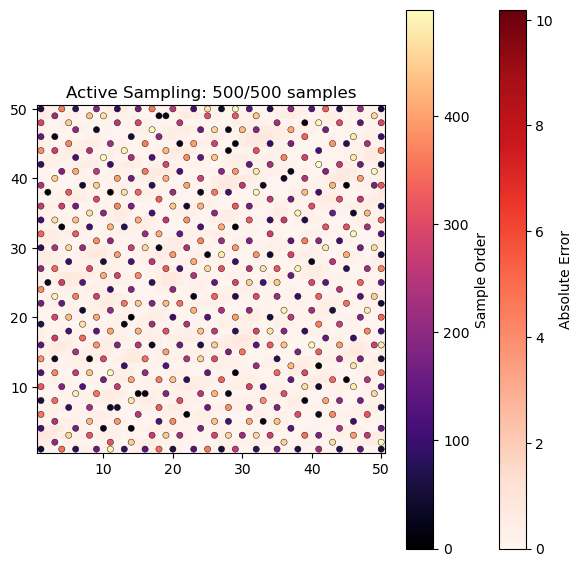

Saved active_estimation_error_evolution.gif


In [22]:
# Figure 4: Animated GIF — Error heatmap + active sample progression
from matplotlib.animation import FuncAnimation, PillowWriter

gif_fps = 10

fig_gif, ax_gif = plt.subplots(figsize=(7, 7))
extent = [0.5, grid_size + 0.5, 0.5, grid_size + 0.5]

# Determine shared color scale across all frames
vmax_err = max(float(e.max()) for e in error_frames)

# Initial heatmap
im = ax_gif.imshow(
    error_frames[0].T,
    origin="lower",
    cmap="Reds",
    extent=extent,
    vmin=0,
    vmax=vmax_err,
)
plt.colorbar(im, ax=ax_gif, label="Absolute Error")

# Sample scatter — coloured by order
sample_cmap = plt.cm.magma
sample_norm = plt.Normalize(vmin=0, vmax=n_total - 1)
scat = ax_gif.scatter([], [], s=20, edgecolors="k", linewidths=0.3)

sm = plt.cm.ScalarMappable(cmap=sample_cmap, norm=sample_norm)
sm.set_array([])
plt.colorbar(sm, ax=ax_gif, label="Sample Order")

ax_gif.set_xlim(extent[0], extent[1])
ax_gif.set_ylim(extent[2], extent[3])
ax_gif.set_aspect("equal")
title = ax_gif.set_title("")


def update(frame_idx):
    n = frame_counts[frame_idx]
    # Update error heatmap
    im.set_data(error_frames[frame_idx].T)
    # Update sample scatter
    xs = X_train_act[:n, 0]
    ys = X_train_act[:n, 1]
    scat.set_offsets(jnp.column_stack([xs, ys]))
    scat.set_facecolors(sample_cmap(sample_norm(jnp.arange(n))))
    title.set_text(f"Active Sampling: {n}/{n_total} samples")
    return im, scat, title


anim = FuncAnimation(
    fig_gif, update, frames=len(frame_counts), blit=True, repeat=False
)
anim.save(
    "plots/active_estimation/active_estimation_error_evolution.gif",
    writer=PillowWriter(fps=gif_fps),
)
plt.show()
print("Saved active_estimation_error_evolution.gif")